<a href="https://colab.research.google.com/github/apoorwa46/ML-Project/blob/main/AQI_PBL1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Step 2: Upload your CSV dataset

uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File:", file_name)
print("Dataset shape:", df.shape)

df.head()

Saving city_day.csv to city_day (1).csv
Dataset loaded successfully!
File: city_day (1).csv
Dataset shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
# Step 3: Dataset familiarization

print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical summary:")
display(df.describe(include="all").T)


Number of rows and columns: (29531, 16)

Column names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI      

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-06-26,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86


In [5]:
# Step 4: Missing values and duplicate records

print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values percentage:")
display((df.isnull().mean() * 100).round(2).sort_values(
    ascending=False
))

Missing values per column:


,0
Xylene,18109
PM10,11140
NH3,10328
Toluene,8041
Benzene,5623
AQI,4681
AQI_Bucket,4681
PM2.5,4598
NOx,4185
O3,4022



Duplicate rows: 0

Missing values percentage:


,0
Xylene,61.32
PM10,37.72
NH3,34.97
Toluene,27.23
Benzene,19.04
AQI,15.85
AQI_Bucket,15.85
PM2.5,15.57
NOx,14.17
O3,13.62


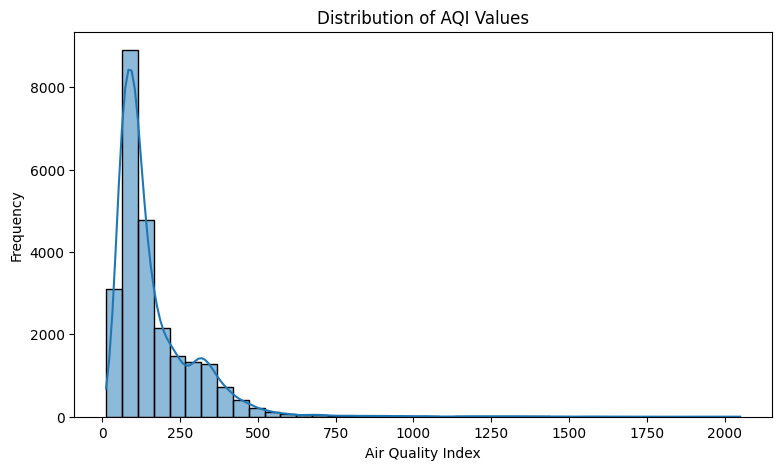

In [6]:
# Step 5A: AQI distribution

if "AQI" in df.columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(df["AQI"].dropna(), bins=40, kde=True)
    plt.title("Distribution of AQI Values")
    plt.xlabel("Air Quality Index")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("AQI column not found. Check the dataset columns.")

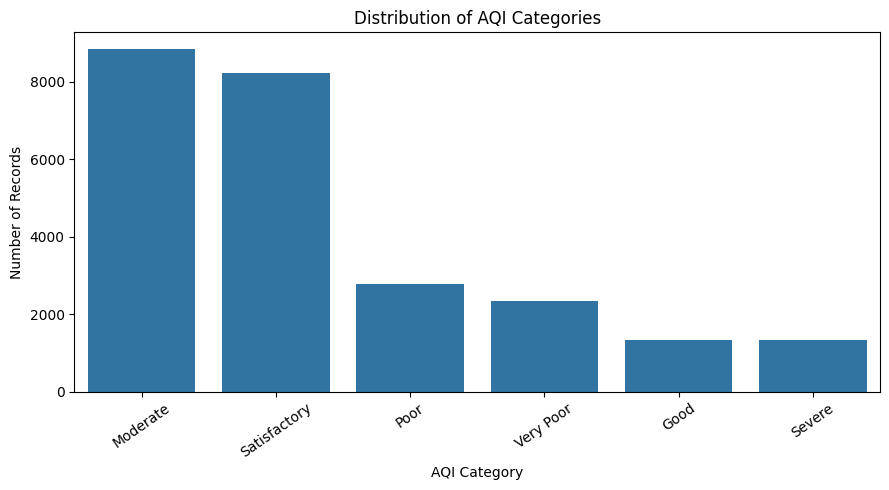

In [7]:
# Step 5B: AQI category distribution

if "AQI_Bucket" in df.columns:
    plt.figure(figsize=(9, 5))
    sns.countplot(
        data=df,
        x="AQI_Bucket",
        order=df["AQI_Bucket"].value_counts().index
    )
    plt.title("Distribution of AQI Categories")
    plt.xlabel("AQI Category")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

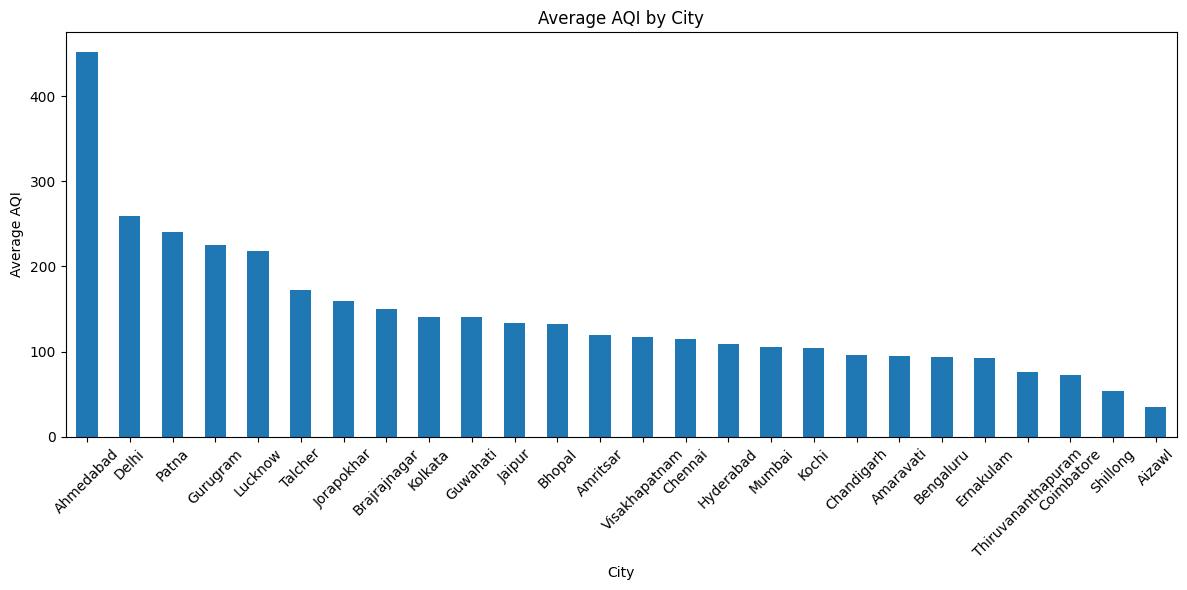

In [8]:
# Step 5C: Average AQI by city

if {"City", "AQI"}.issubset(df.columns):
    city_aqi = (
        df.groupby("City")["AQI"]
        .mean()
        .dropna()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    city_aqi.plot(kind="bar")
    plt.title("Average AQI by City")
    plt.xlabel("City")
    plt.ylabel("Average AQI")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


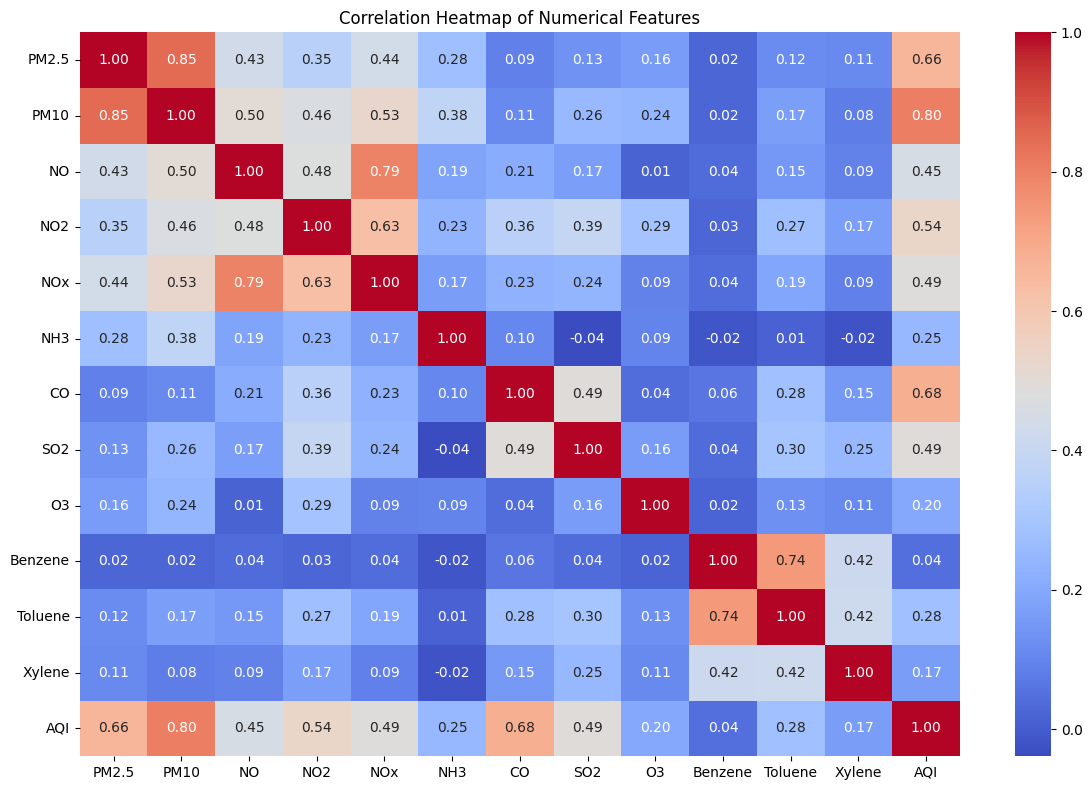

In [9]:
# Step 5D: Correlation heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

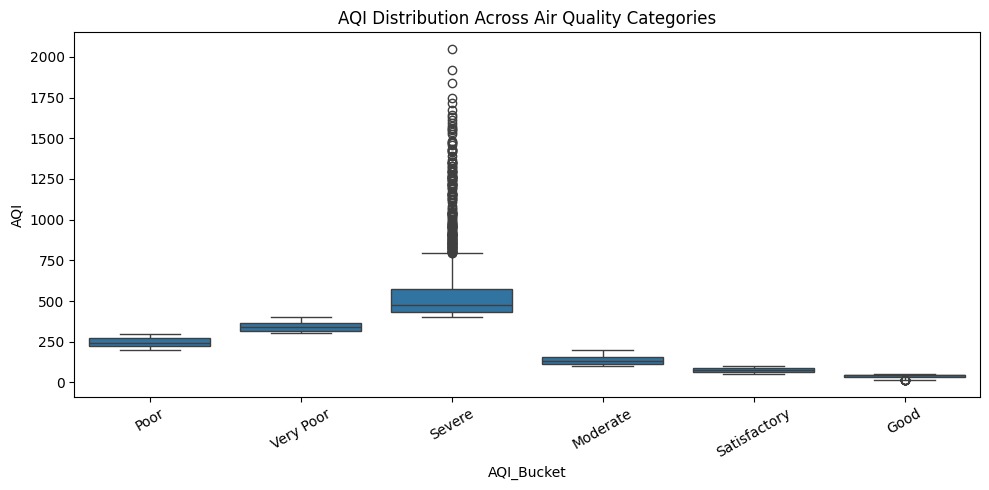

In [10]:

# Chart 1: AQI by category — boxplot

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="AQI_Bucket", y="AQI")
plt.title("AQI Distribution Across Air Quality Categories")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


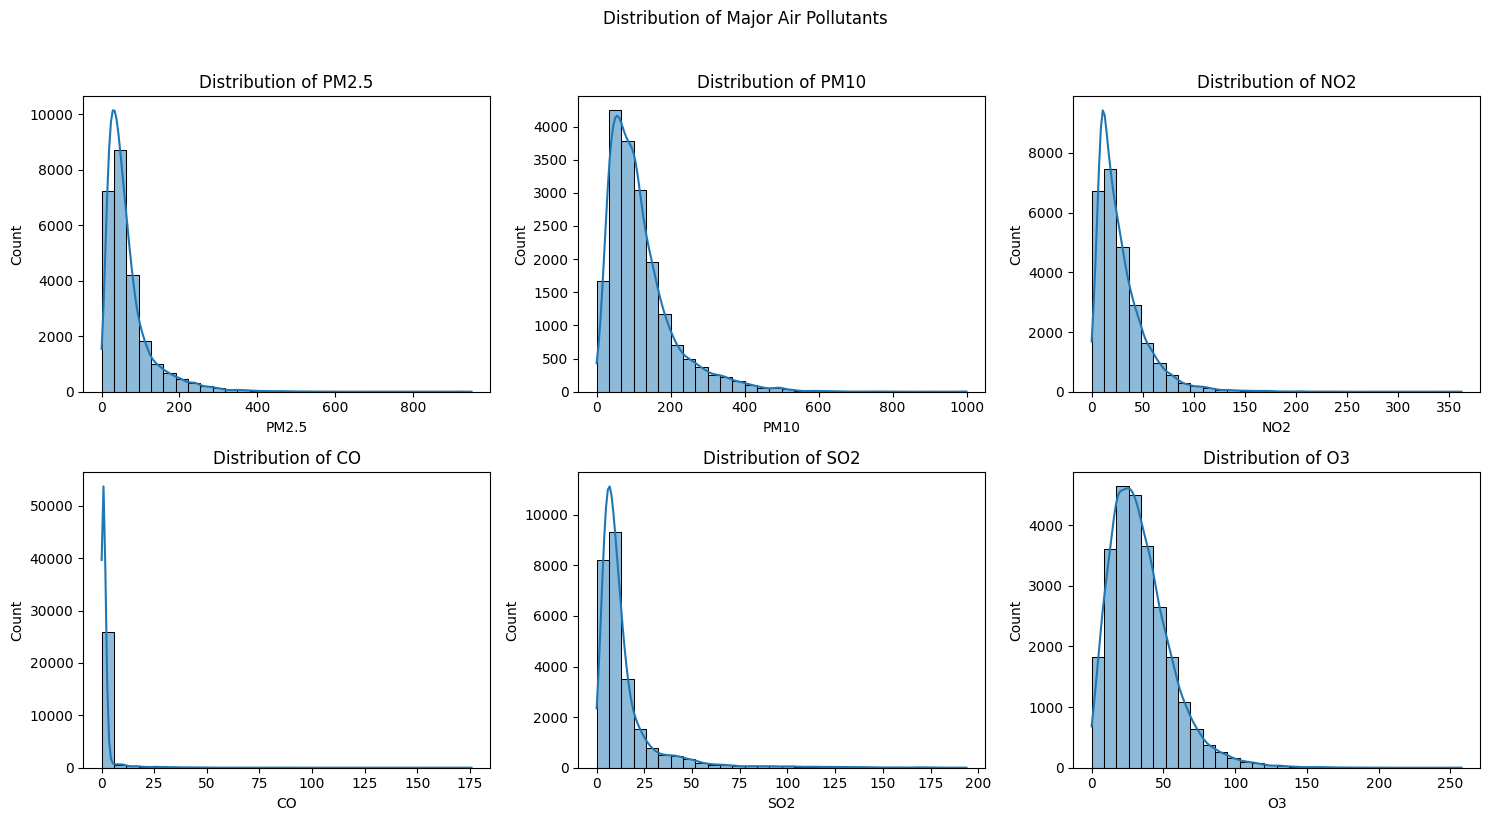

In [11]:

# Chart 2: Distribution of major pollutants

pollutants = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, ax in zip(pollutants, axes.flatten()):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.suptitle("Distribution of Major Air Pollutants", y=1.02)
plt.tight_layout()
plt.show()


In [12]:

# Step 6: Analyze missing values and duplicates

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

display(missing.sort_values("Missing_Percentage", ascending=False))

print("Duplicate rows:", df.duplicated().sum())
print("Rows with missing AQI:", df["AQI"].isnull().sum())
print("Rows with missing AQI_Bucket:", df["AQI_Bucket"].isnull().sum())

print("\nAQI category counts:")
print(df["AQI_Bucket"].value_counts(dropna=False))


,Missing_Count,Missing_Percentage
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


Duplicate rows: 0
Rows with missing AQI: 4681
Rows with missing AQI_Bucket: 4681

AQI category counts:
AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Unique cities: 26
Unique dates: 2009


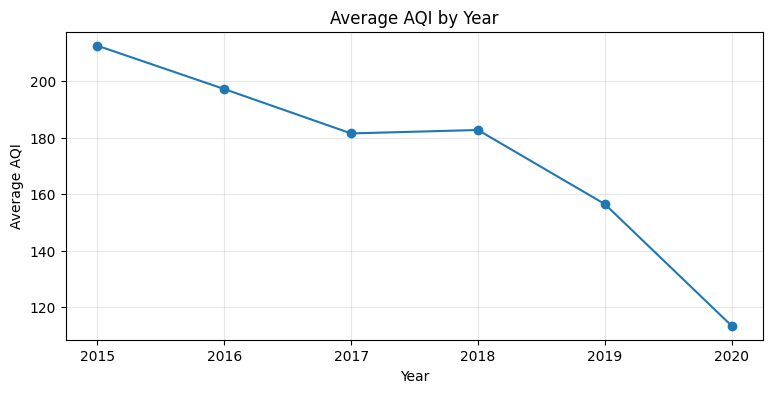

In [13]:

# Step 7: Date preprocessing

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Unique cities:", df["City"].nunique())
print("Unique dates:", df["Date"].nunique())

# Average AQI by year
if df["AQI"].notna().any():
    yearly_aqi = df.groupby("Year")["AQI"].mean().dropna()

    plt.figure(figsize=(9, 4))
    yearly_aqi.plot(marker="o")
    plt.title("Average AQI by Year")
    plt.xlabel("Year")
    plt.ylabel("Average AQI")
    plt.grid(alpha=0.3)
    plt.show()



,Correlation_with_AQI
PM10,0.803313
CO,0.683346
PM2.5,0.659181
NO2,0.537071
SO2,0.490586
NOx,0.486450
NO,0.452191
Toluene,0.279992
NH3,0.252019
O3,0.198991


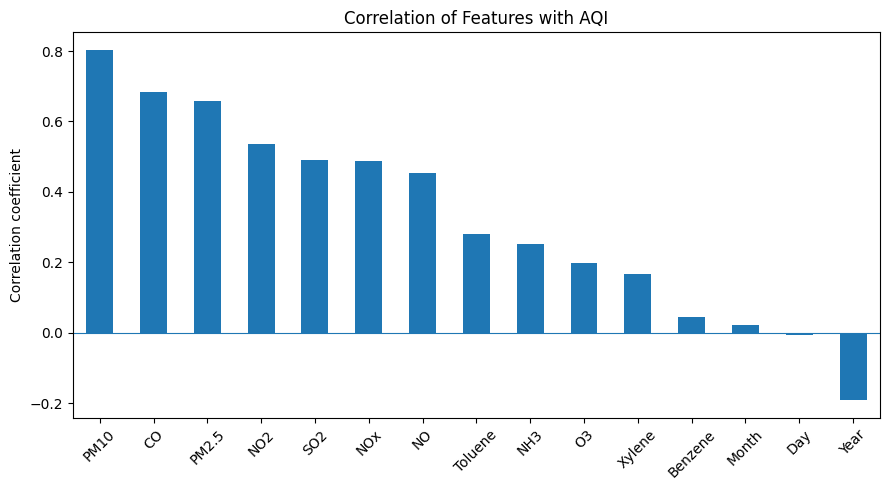

In [14]:

# Step 8: Correlation of pollutants with AQI

numeric_df = df.select_dtypes(include=np.number)
correlations = numeric_df.corr()["AQI"].drop("AQI").dropna()
correlations = correlations.sort_values(ascending=False)

display(correlations.to_frame("Correlation_with_AQI"))

plt.figure(figsize=(9, 5))
correlations.plot(kind="bar")
plt.title("Correlation of Features with AQI")
plt.ylabel("Correlation coefficient")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=0.8)
plt.tight_layout()
plt.show()


In [15]:

# Step 10: Import ML libraries

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Machine learning libraries imported successfully!")


Machine learning libraries imported successfully!


In [16]:

# Step 11: Feature preparation

data = df.copy()

# Convert Date and extract useful features
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day

# Pollutant measurements
pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"
]

# Keep features that actually exist in the dataset
pollutants = [c for c in pollutants if c in data.columns]

# Common input features
feature_cols = pollutants + ["City", "Year", "Month", "Day"]

# Regression dataset: target is numerical AQI
reg_data = data.dropna(subset=["AQI"]).copy()
X_reg = reg_data[feature_cols]
y_reg = reg_data["AQI"]

# Classification dataset: target is AQI category
cls_data = data.dropna(subset=["AQI_Bucket"]).copy()
X_cls = cls_data[feature_cols]
y_cls = cls_data["AQI_Bucket"].astype(str)

print("Regression records:", len(reg_data))
print("Classification records:", len(cls_data))
print("Input features:", feature_cols)
print("\nAQI categories:")
print(y_cls.value_counts())


Regression records: 24850
Classification records: 24850
Input features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'City', 'Year', 'Month', 'Day']

AQI categories:
AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [17]:

# Step 12: Preprocessing pipelines

numeric_features = pollutants + ["Year", "Month", "Day"]
categorical_features = ["City"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


In [18]:

# Step 13: Train regression models

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=42
)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
}

regression_results = []
trained_regression_models = {}

for name, model in regression_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_reg, y_train_reg)
    predictions = pipeline.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    r2 = r2_score(y_test_reg, predictions)

    regression_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_regression_models[name] = pipeline

regression_results_df = pd.DataFrame(regression_results)
display(regression_results_df.round(3))


,Model,MAE,RMSE,R2 Score
0,Linear Regression,29.978,56.704,0.824
1,Random Forest Regressor,20.407,40.282,0.911


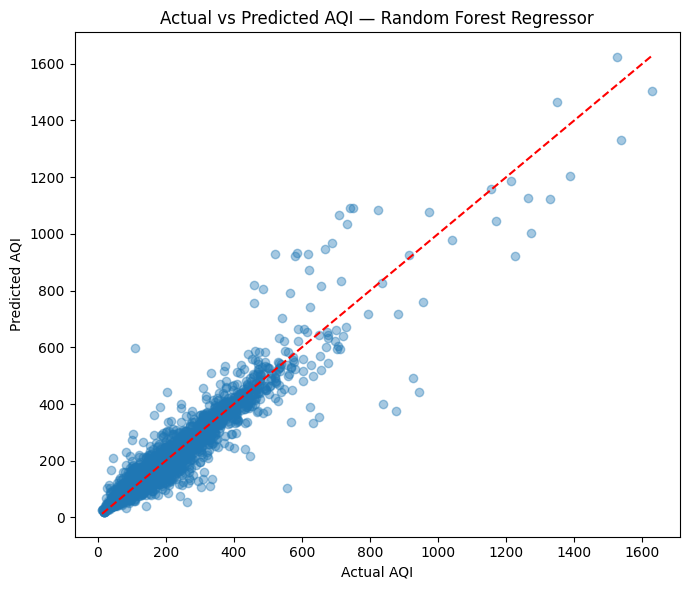

Best regression model by RMSE: Random Forest Regressor


In [19]:

# Step 14: Actual vs predicted AQI

best_reg_name = regression_results_df.sort_values(
    "RMSE"
).iloc[0]["Model"]

best_reg_model = trained_regression_models[best_reg_name]
reg_predictions = best_reg_model.predict(X_test_reg)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, reg_predictions, alpha=0.4)

min_val = min(y_test_reg.min(), reg_predictions.min())
max_val = max(y_test_reg.max(), reg_predictions.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title(f"Actual vs Predicted AQI — {best_reg_name}")
plt.tight_layout()
plt.show()

print("Best regression model by RMSE:", best_reg_name)


In [20]:

# Step 15: Train classification models

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
}

classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_cls, y_train_cls)
    predictions = pipeline.predict(X_test_cls)

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_cls, predictions),
        "Precision (Macro)": precision_score(
            y_test_cls, predictions,
            average="macro", zero_division=0
        ),
        "Recall (Macro)": recall_score(
            y_test_cls, predictions,
            average="macro", zero_division=0
        ),
        "F1 (Macro)": f1_score(
            y_test_cls, predictions,
            average="macro", zero_division=0
        )
    })

    trained_classification_models[name] = pipeline

classification_results_df = pd.DataFrame(classification_results)
display(classification_results_df.round(3))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Logistic Regression,0.726,0.691,0.762,0.709
1,Random Forest Classifier,0.812,0.802,0.776,0.788


Best classification model by macro F1: Random Forest Classifier

Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.70      0.74       268
    Moderate       0.82      0.85      0.83      1766
        Poor       0.73      0.66      0.69       556
Satisfactory       0.84      0.85      0.85      1645
      Severe       0.87      0.79      0.83       268
   Very Poor       0.78      0.81      0.79       467

    accuracy                           0.81      4970
   macro avg       0.80      0.78      0.79      4970
weighted avg       0.81      0.81      0.81      4970



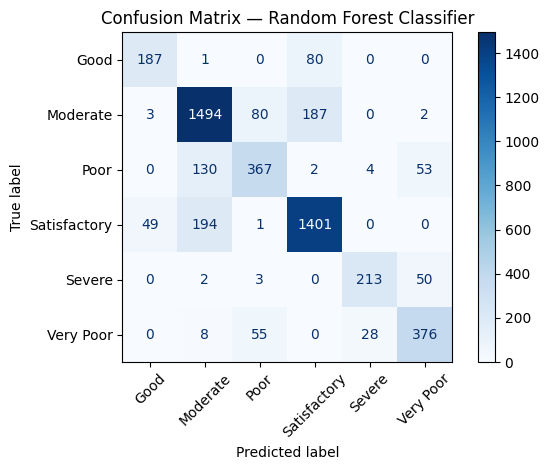

In [21]:

# Step 16: Evaluate the best classification model by macro F1

best_cls_name = classification_results_df.sort_values(
    "F1 (Macro)", ascending=False
).iloc[0]["Model"]

best_cls_model = trained_classification_models[best_cls_name]
cls_predictions = best_cls_model.predict(X_test_cls)

print("Best classification model by macro F1:", best_cls_name)
print("\nClassification Report:")
print(classification_report(
    y_test_cls,
    cls_predictions,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    cls_predictions,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title(f"Confusion Matrix — {best_cls_name}")
plt.tight_layout()
plt.show()


In [22]:

# Step 17: Compare models separately by task

print("REGRESSION MODEL COMPARISON")
display(
    regression_results_df.sort_values("RMSE").round(3)
)

print("CLASSIFICATION MODEL COMPARISON")
display(
    classification_results_df.sort_values(
        "F1 (Macro)", ascending=False
    ).round(3)
)


REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
1,Random Forest Regressor,20.407,40.282,0.911
0,Linear Regression,29.978,56.704,0.824


CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
1,Random Forest Classifier,0.812,0.802,0.776,0.788
0,Logistic Regression,0.726,0.691,0.762,0.709


In [23]:

# Step 19: Add more regression models

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

additional_regressors = {
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=2,
        random_state=42
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    "Support Vector Regressor": SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1
    )
}

for name, model in additional_regressors.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_reg, y_train_reg)
    predictions = pipeline.predict(X_test_reg)

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, predictions)),
        "R2 Score": r2_score(y_test_reg, predictions)
    })

    trained_regression_models[name] = pipeline

regression_results_df = (
    pd.DataFrame(regression_results)
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(regression_results_df.round(3))


,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,20.407,40.282,0.911
1,Gradient Boosting Regressor,23.159,43.194,0.898
2,Decision Tree Regressor,24.443,50.366,0.861
3,Linear Regression,29.978,56.704,0.824
4,Support Vector Regressor,25.397,63.647,0.779


In [24]:

# Step 20: Add more classification models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

additional_classifiers = {
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=15,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    "Support Vector Classifier": SVC(
        kernel="rbf",
        C=1,
        class_weight="balanced"
    )
}

for name, model in additional_classifiers.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_cls, y_train_cls)
    predictions = pipeline.predict(X_test_cls)

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_cls, predictions),
        "Precision (Macro)": precision_score(
            y_test_cls, predictions,
            average="macro", zero_division=0
        ),
        "Recall (Macro)": recall_score(
            y_test_cls, predictions,
            average="macro", zero_division=0
        ),
        "F1 (Macro)": f1_score(
            y_test_cls, predictions,
            average="macro", zero_division=0
        )
    })

    trained_classification_models[name] = pipeline

classification_results_df = (
    pd.DataFrame(classification_results)
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("F1 (Macro)", ascending=False)
    .reset_index(drop=True)
)

display(classification_results_df.round(3))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Random Forest Classifier,0.812,0.802,0.776,0.788
1,Gradient Boosting Classifier,0.810,0.798,0.770,0.783
2,Support Vector Classifier,0.758,0.716,0.791,0.739
3,Decision Tree Classifier,0.758,0.715,0.754,0.731
4,Logistic Regression,0.726,0.691,0.762,0.709


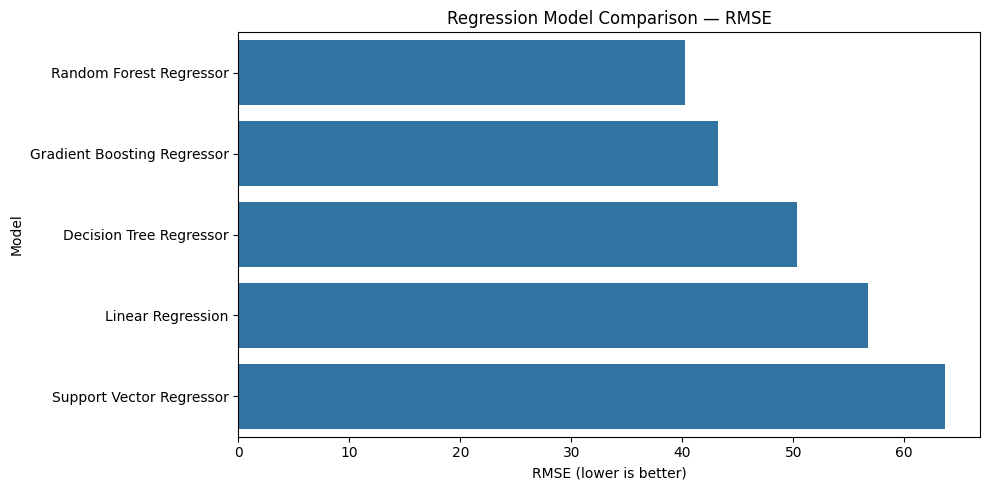

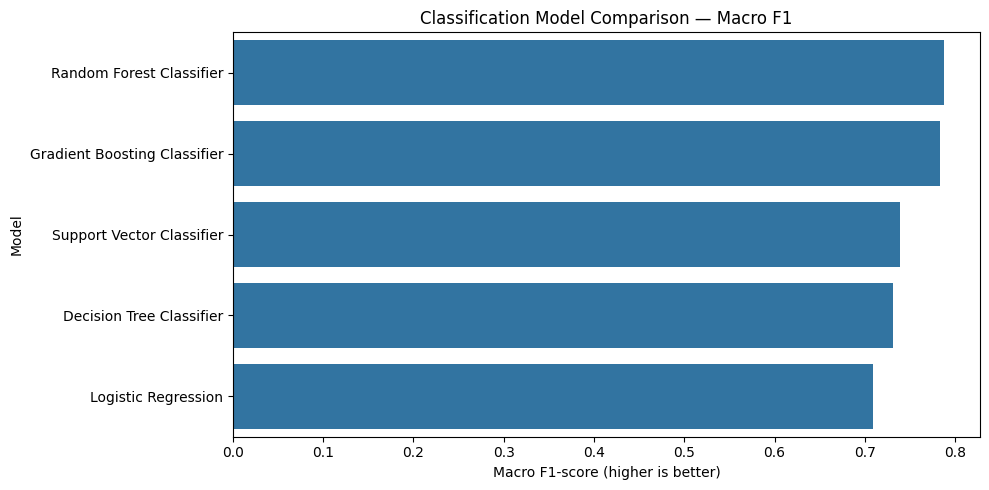

FINAL REGRESSION RANKING


,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,20.407,40.282,0.911
1,Gradient Boosting Regressor,23.159,43.194,0.898
2,Decision Tree Regressor,24.443,50.366,0.861
3,Linear Regression,29.978,56.704,0.824
4,Support Vector Regressor,25.397,63.647,0.779


FINAL CLASSIFICATION RANKING


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Random Forest Classifier,0.812,0.802,0.776,0.788
1,Gradient Boosting Classifier,0.810,0.798,0.770,0.783
2,Support Vector Classifier,0.758,0.716,0.791,0.739
3,Decision Tree Classifier,0.758,0.715,0.754,0.731
4,Logistic Regression,0.726,0.691,0.762,0.709


In [25]:

# Step 21A: Compare regression models by RMSE

plt.figure(figsize=(10, 5))
sns.barplot(
    data=regression_results_df,
    x="RMSE",
    y="Model"
)
plt.title("Regression Model Comparison — RMSE")
plt.xlabel("RMSE (lower is better)")
plt.tight_layout()
plt.show()


# Step 21B: Compare classification models by macro F1

plt.figure(figsize=(10, 5))
sns.barplot(
    data=classification_results_df,
    x="F1 (Macro)",
    y="Model"
)
plt.title("Classification Model Comparison — Macro F1")
plt.xlabel("Macro F1-score (higher is better)")
plt.tight_layout()
plt.show()


# Display final tables
print("FINAL REGRESSION RANKING")
display(regression_results_df.round(3))

print("FINAL CLASSIFICATION RANKING")
display(classification_results_df.round(3))


Top 15 features influencing AQI predictions:


,Feature,Importance
0,numeric__PM2.5,0.4913
6,numeric__CO,0.3659
2,numeric__NO,0.0362
1,numeric__PM10,0.0353
8,numeric__O3,0.0124
4,numeric__NOx,0.0093
7,numeric__SO2,0.0078
10,numeric__Toluene,0.0060
3,numeric__NO2,0.0058
14,numeric__Day,0.0053


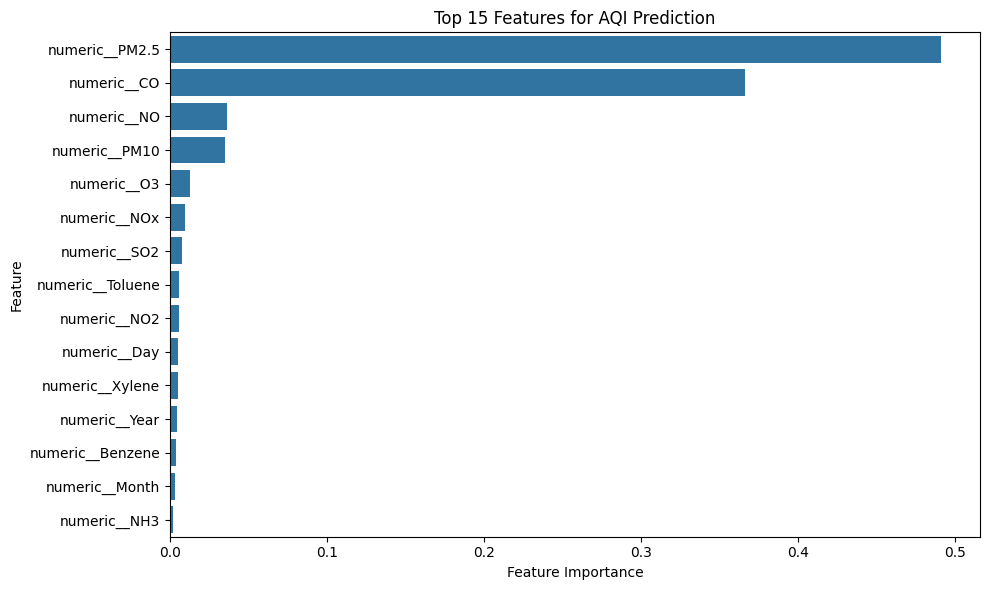

In [26]:

# Step 22: Feature importance of Random Forest Regressor

rf_pipeline = trained_regression_models["Random Forest Regressor"]

feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Top 15 features influencing AQI predictions:")
display(importance_df.head(15).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Features for AQI Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


,Feature,Importance,Std
0,PM2.5,50.7187,0.4018
6,CO,24.8366,0.7064
1,PM10,16.8862,0.3321
8,O3,3.1564,0.0933
12,City,2.4019,0.1719
2,NO,2.1128,0.1490
4,NOx,1.1895,0.0329
13,Year,0.7077,0.0395
3,NO2,0.3798,0.0378
10,Toluene,0.3615,0.0156


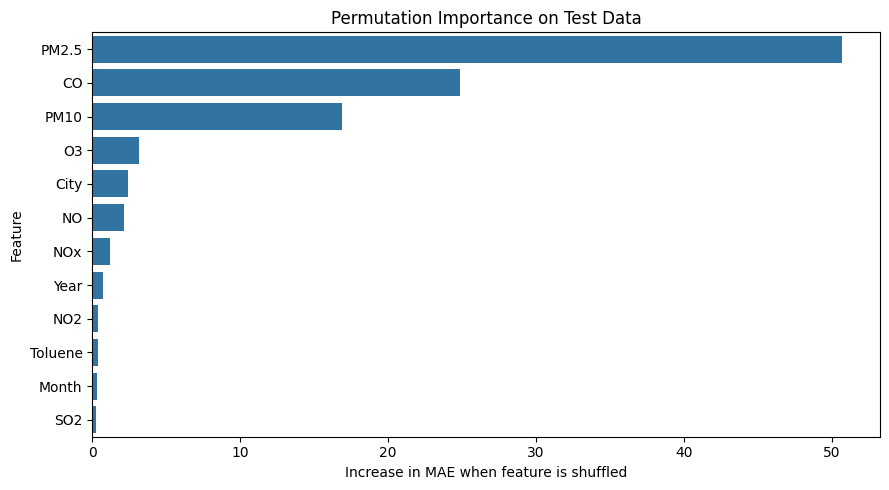

In [27]:

from sklearn.inspection import permutation_importance

rf_pipeline = trained_regression_models["Random Forest Regressor"]

perm = permutation_importance(
    rf_pipeline,
    X_test_reg,
    y_test_reg,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test_reg.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False)

display(perm_df.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=perm_df.head(12),
    x="Importance",
    y="Feature"
)
plt.title("Permutation Importance on Test Data")
plt.xlabel("Increase in MAE when feature is shuffled")
plt.tight_layout()
plt.show()


Top 15 features for AQI category classification:


,Feature,Importance
0,numeric__PM2.5,0.2211
1,numeric__PM10,0.1333
6,numeric__CO,0.1117
2,numeric__NO,0.0638
8,numeric__O3,0.0553
4,numeric__NOx,0.0493
7,numeric__SO2,0.0486
3,numeric__NO2,0.0486
10,numeric__Toluene,0.0392
5,numeric__NH3,0.0355


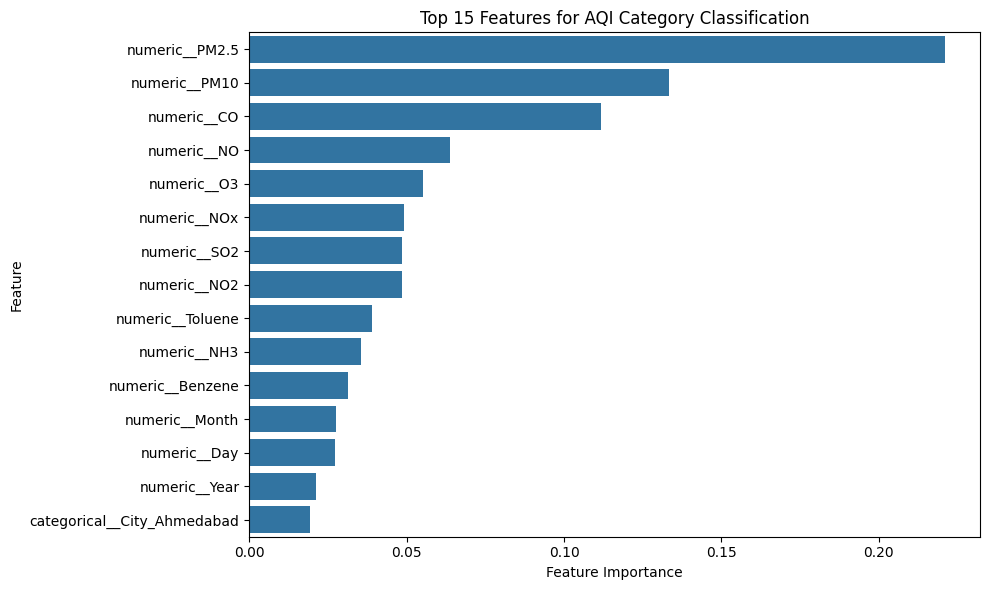

In [28]:

# Step 23: Feature importance for Random Forest Classifier

rf_classifier = trained_classification_models[
    "Random Forest Classifier"
]

feature_names_cls = (
    rf_classifier.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances_cls = (
    rf_classifier.named_steps["model"]
    .feature_importances_
)

importance_cls_df = pd.DataFrame({
    "Feature": feature_names_cls,
    "Importance": importances_cls
}).sort_values("Importance", ascending=False)

print("Top 15 features for AQI category classification:")
display(importance_cls_df.head(15).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_cls_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Features for AQI Category Classification")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Random Forest Classifier Evaluation
Accuracy: 0.8125

Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.70      0.74       268
    Moderate       0.82      0.85      0.83      1766
        Poor       0.73      0.66      0.69       556
Satisfactory       0.84      0.85      0.85      1645
      Severe       0.87      0.79      0.83       268
   Very Poor       0.78      0.81      0.79       467

    accuracy                           0.81      4970
   macro avg       0.80      0.78      0.79      4970
weighted avg       0.81      0.81      0.81      4970



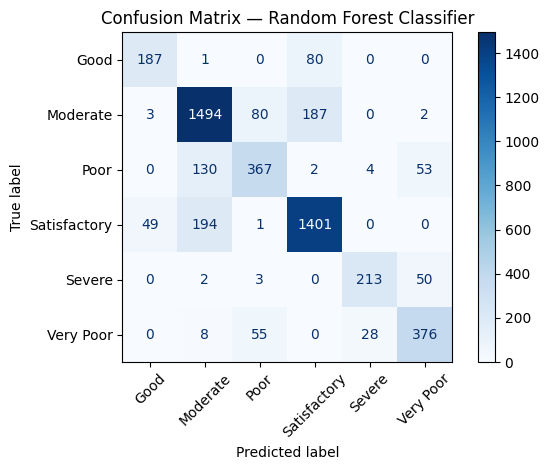

In [29]:

# Step 24: Confusion matrix for Random Forest Classifier

rf_classifier = trained_classification_models[
    "Random Forest Classifier"
]

rf_cls_predictions = rf_classifier.predict(X_test_cls)

print("Random Forest Classifier Evaluation")
print("Accuracy:", round(
    accuracy_score(y_test_cls, rf_cls_predictions), 4
))

print("\nClassification Report:")
print(classification_report(
    y_test_cls,
    rf_cls_predictions,
    zero_division=0
))

ConfusionMatrixDisplay.from_estimator(
    rf_classifier,
    X_test_cls,
    y_test_cls,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix — Random Forest Classifier")
plt.tight_layout()
plt.show()


,Feature,Importance,Std
0,PM2.5,0.2693,0.0082
1,PM10,0.1386,0.0056
6,CO,0.1224,0.0028
8,O3,0.0431,0.0019
2,NO,0.0220,0.0028
4,NOx,0.0148,0.0029
12,City,0.0127,0.0022
13,Year,0.0112,0.0025
5,NH3,0.0086,0.0007
3,NO2,0.0054,0.0020


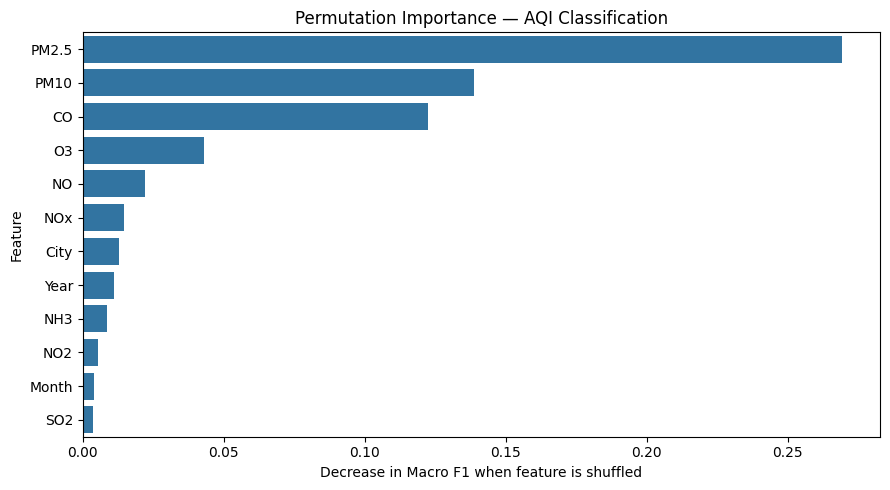

In [30]:

# Step 25: Permutation importance for classification

from sklearn.inspection import permutation_importance

perm_cls = permutation_importance(
    rf_classifier,
    X_test_cls,
    y_test_cls,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_cls_df = pd.DataFrame({
    "Feature": X_test_cls.columns,
    "Importance": perm_cls.importances_mean,
    "Std": perm_cls.importances_std
}).sort_values("Importance", ascending=False)

display(perm_cls_df.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=perm_cls_df.head(12),
    x="Importance",
    y="Feature"
)
plt.title("Permutation Importance — AQI Classification")
plt.xlabel("Decrease in Macro F1 when feature is shuffled")
plt.tight_layout()
plt.show()


**# Final Results Summary**

In [31]:

# Final Results Summary

best_reg = regression_results_df.sort_values("RMSE").iloc[0]
best_cls = classification_results_df.sort_values(
    "F1 (Macro)", ascending=False
).iloc[0]

print("=" * 55)
print("AQI PREDICTION - FINAL RESULTS")
print("=" * 55)

print("\nBEST REGRESSION MODEL")
print("Model:", best_reg["Model"])
print(f"MAE: {best_reg['MAE']:.3f}")
print(f"RMSE: {best_reg['RMSE']:.3f}")
print(f"R2 Score: {best_reg['R2 Score']:.3f}")

print("\nBEST CLASSIFICATION MODEL")
print("Model:", best_cls["Model"])
print(f"Accuracy: {best_cls['Accuracy']:.3f}")
print(f"Macro Precision: {best_cls['Precision (Macro)']:.3f}")
print(f"Macro Recall: {best_cls['Recall (Macro)']:.3f}")
print(f"Macro F1: {best_cls['F1 (Macro)']:.3f}")

print("\nREGRESSION MODELS TESTED:", len(regression_results_df))
print("CLASSIFICATION MODELS TESTED:",
      len(classification_results_df))


AQI PREDICTION - FINAL RESULTS

BEST REGRESSION MODEL
Model: Random Forest Regressor
MAE: 20.407
RMSE: 40.282
R2 Score: 0.911

BEST CLASSIFICATION MODEL
Model: Random Forest Classifier
Accuracy: 0.812
Macro Precision: 0.802
Macro Recall: 0.776
Macro F1: 0.788

REGRESSION MODELS TESTED: 5
CLASSIFICATION MODELS TESTED: 5


## Conclusion

The project successfully implemented a machine learning approach for Air Quality Index (AQI) estimation and AQI category classification using air-quality data from Indian cities.

Exploratory Data Analysis was performed to understand the distribution of AQI, missing values, differences between cities, and relationships among pollutant measurements.

Five regression algorithms were compared: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and Support Vector Regressor. Random Forest Regressor achieved the best results, with an MAE of 20.407, RMSE of 40.282, and R² score of 0.911.

Five classification algorithms were also evaluated. Random Forest Classifier achieved the highest overall accuracy of 81.2% and a macro F1-score of 0.788 among the tested models.

Feature-importance analysis highlighted PM2.5, PM10, and CO as important predictive features. The classification confusion matrix also identified the Poor category as an area for improvement.

Overall, the results demonstrate the potential of machine learning for estimating AQI from pollutant measurements and classifying air-quality categories. Future work could investigate chronological validation, improved handling of missing data, hyperparameter tuning, and forecasting future AQI values.

## Limitation

Missing data: Some pollutant measurements have substantial missingness, especially Xylene.



Model generalization: The random train-test split does not establish performance on future dates or unseen cities.



Classification errors: The Poor category has relatively low recall, around 66%.



Estimation versus forecasting: The current models estimate AQI from measurements of the same record. Predicting future AQI would require a time-series or forecasting setup.



Feature importance: Importance scores indicate predictive usefulness, not causal effects.